# ML Project 02 – Adult Income Classification

## Objective

The aim of this project is to predict whether a person earns more than $50K per year using the Adult Census Income dataset.

This is a binary classification problem.

Target variable:

- `<=50K` → 0
- `>50K` → 1

This notebook follows a similar workflow to the Customer Churn neural network exercise:

1. Load the dataset
2. Inspect the data
3. Clean missing values
4. Perform exploratory data analysis
5. Encode categorical variables
6. Scale numerical variables
7. Train TensorFlow/Keras model
8. Train PyTorch model
9. Compare model performance

In [3]:
import pandas as pd #  for handling table data
import numpy as np # for handling numerical data

pd.set_option("display.max.columns",None)

In [8]:
df=pd.read_csv("../data/adult.csv")
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [9]:
df.shape

(32561, 15)

In [10]:
df. columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education.num',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital.gain',
 'capital.loss',
 'hours.per.week',
 'native.country',
 'income']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [12]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

## Initial Data Check

The dataset contains 32,561 rows and 15 columns.

The target column is `income`.

This is a binary classification problem:

- `<=50K`
- `>50K`

The dataset is imbalanced because there are more `<=50K` examples than `>50K` examples.

This is similar to the Customer Churn project, where the model learned from customer features to predict churn. Here, the model learns from age, education, occupation, working hours and other features to predict income category.

## 2. Missing Value Check and Cleaning

The dataset does not contain standard blank/null missing values, but some missing entries are stored as `?`.

We need to identify these `?` values and replace them with `NaN` so that the preprocessing pipeline can handle them properly.

In [16]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [17]:
df = df.replace("?", np.nan)

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [18]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

occupation        5.660146
workclass         5.638647
native.country    1.790486
dtype: float64

## Missing Value Observations

The Adult Income dataset stores some missing values as `?`.

After replacing `?` with `NaN`, missing values are visible in columns such as:

- `workclass`
- `occupation`
- `native.country`

These missing values will later be handled during preprocessing using `SimpleImputer`.

For categorical columns, we can replace missing values with the most frequent category.

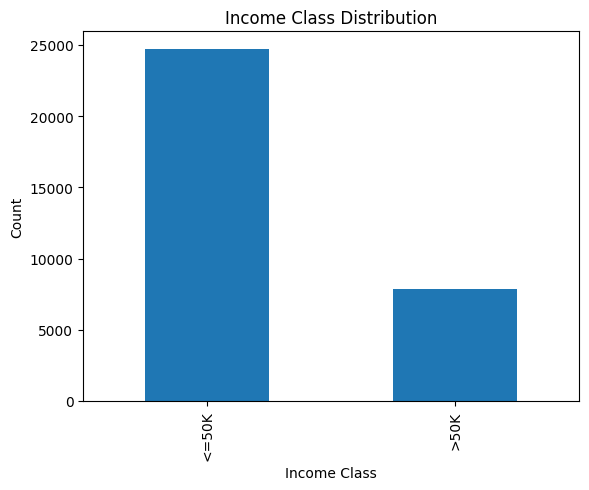

In [19]:
import matplotlib.pyplot as plt

df["income"].value_counts().plot(kind="bar")

plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

## 3. Exploratory Data Analysis

In this section, we explore the dataset before modelling.

We will check:

- Target class balance
- Numerical column distributions
- Categorical column counts
- Relationship between important features and income

In [20]:
import matplotlib.pyplot as plt

In [21]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [22]:
df["income"].value_counts(normalize=True) * 100

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

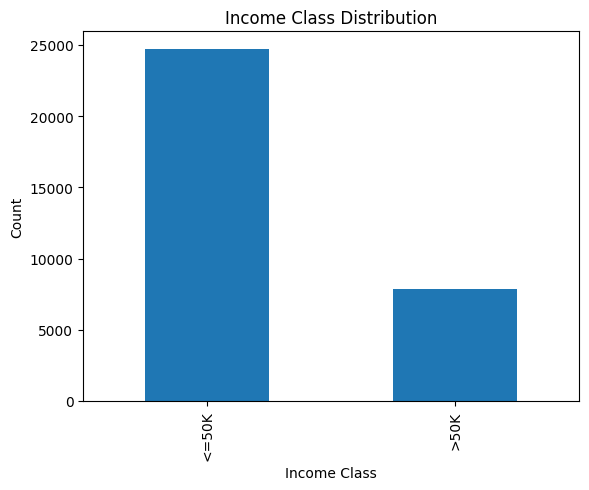

In [23]:
df["income"].value_counts().plot(kind="bar")

plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

### Target Distribution Observation

The dataset is imbalanced.

There are more people earning `<=50K` compared to `>50K`.

Because of this, accuracy alone may not be enough. We should also check precision, recall and F1-score.

In [27]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols
df[numerical_cols].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


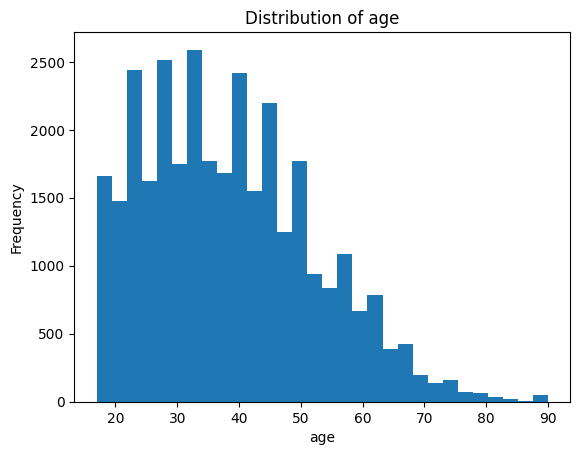

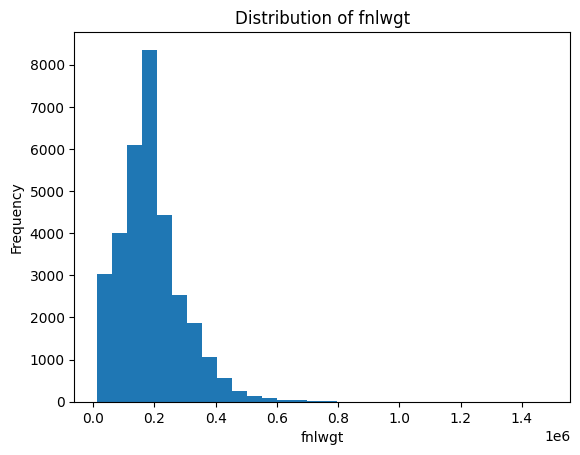

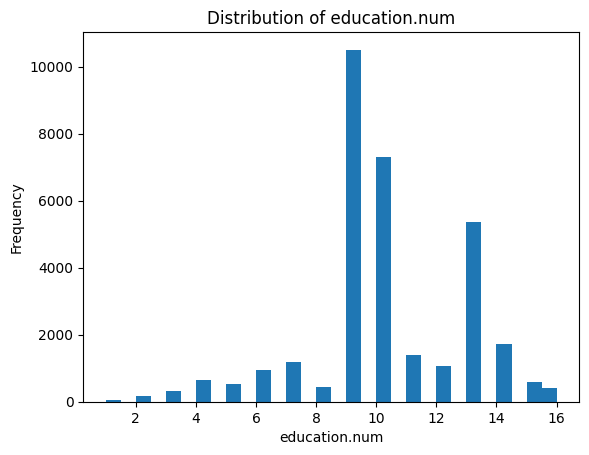

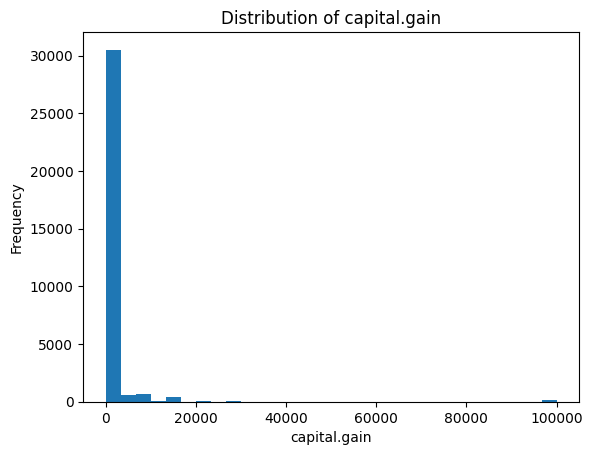

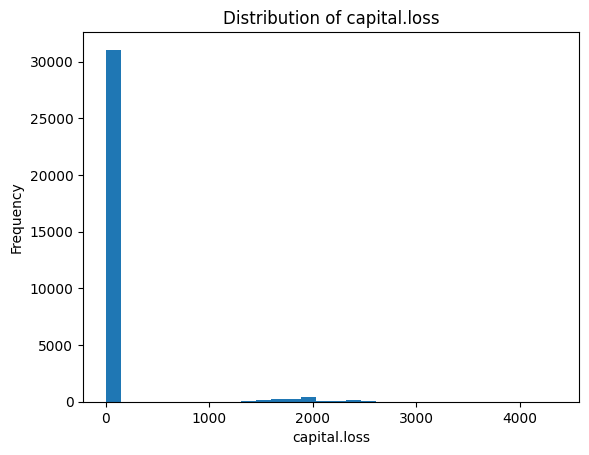

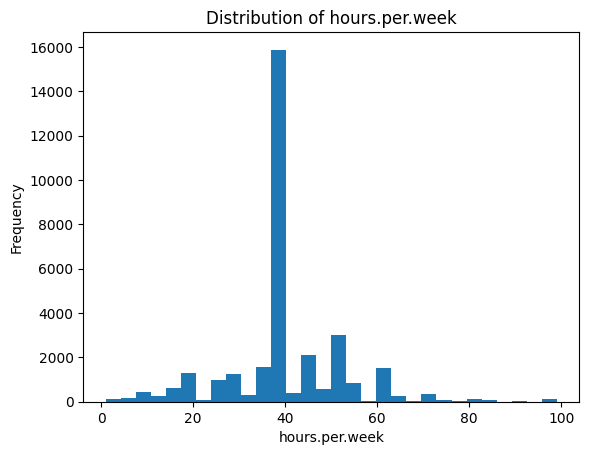

In [28]:
for col in numerical_cols:
    df[col].plot(kind="hist", bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [29]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country',
 'income']

In [30]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [31]:
df["education"].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [32]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [33]:
df["sex"].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

In [34]:
pd.crosstab(df["education"], df["income"])

income,<=50K,>50K
education,,
10th,871,62
11th,1115,60
12th,400,33
1st-4th,162,6
5th-6th,317,16
7th-8th,606,40
9th,487,27
Assoc-acdm,802,265
Assoc-voc,1021,361


In [35]:
pd.crosstab(df["education"], df["income"], normalize="index") * 100

income,<=50K,>50K
education,,
10th,93.354770,6.645230
11th,94.893617,5.106383
12th,92.378753,7.621247
1st-4th,96.428571,3.571429
5th-6th,95.195195,4.804805
7th-8th,93.808050,6.191950
9th,94.747082,5.252918
Assoc-acdm,75.164011,24.835989
Assoc-voc,73.878437,26.121563


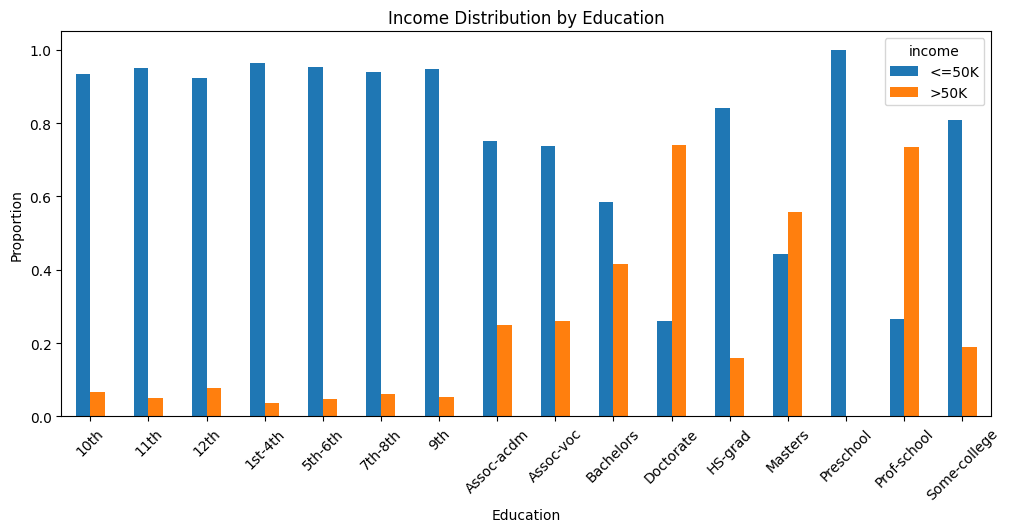

In [36]:
pd.crosstab(df["education"], df["income"], normalize="index").plot(kind="bar", figsize=(12, 5))

plt.title("Income Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

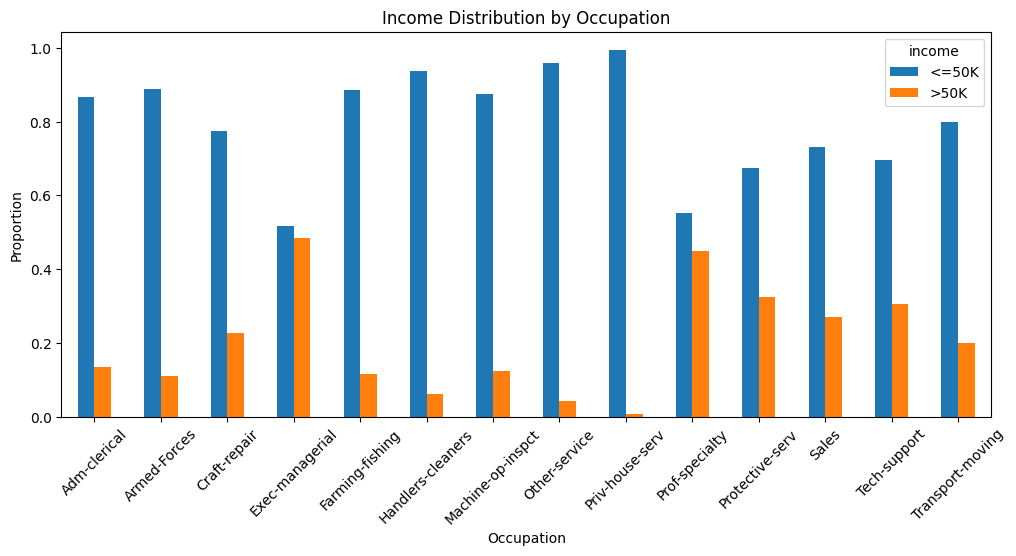

In [37]:
pd.crosstab(df["occupation"], df["income"], normalize="index").plot(kind="bar", figsize=(12, 5))

plt.title("Income Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()


## EDA Observations

From the initial EDA:

- The target variable is imbalanced, with more `<=50K` records than `>50K`.
- The dataset contains both numerical and categorical features.
- `capital.gain` and `capital.loss` contain many zero values.
- Education and occupation appear to have a visible relationship with income.
- Because the dataset contains many categorical columns, one-hot encoding will be needed before training the neural network.

## 4. Feature and Target Split

The target column is `income`.

We will convert the target into binary values:

- `<=50K` → 0
- `>50K` → 1

The remaining columns will be used as input features.

In [38]:
df_model = df.copy()

df_model.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [39]:
df_model = df.copy()

df_model.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [40]:
df_model["income"] = df_model["income"].map({
    "<=50K": 0,
    ">50K": 1
})

df_model["income"].value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

In [41]:
X = df_model.drop("income", axis=1)
y = df_model["income"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32561, 14)
y shape: (32561,)


In [42]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Categorical columns:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


## Feature Type Observation

The dataset contains both numerical and categorical features.

Numerical columns will be scaled using `StandardScaler`.

Categorical columns will be converted into numbers using `OneHotEncoder`.

Missing categorical values will be handled using `SimpleImputer` with the most frequent value.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (26048, 14)
X_test: (6513, 14)
y_train: (26048,)
y_test: (6513,)


In [44]:
print(X_train.iloc[0])
print(y_train.iloc[0])

age                           34
workclass                Private
fnlwgt                    176831
education              Bachelors
education.num                 13
marital.status          Divorced
occupation        Prof-specialty
relationship           Unmarried
race                       White
sex                       Female
capital.gain                   0
capital.loss                   0
hours.per.week                40
native.country     United-States
Name: 11219, dtype: object
1


In [45]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
income
0    75.917537
1    24.082463
Name: proportion, dtype: float64

Testing target distribution:
income
0    75.925073
1    24.074927
Name: proportion, dtype: float64


## 5. Preprocessing Pipeline

Before training the neural network, the data must be converted into numerical format.

Steps:

1. Numerical columns:
   - Fill missing values using median
   - Scale values using `StandardScaler`

2. Categorical columns:
   - Fill missing values using most frequent category
   - Convert text categories into numerical columns using `OneHotEncoder`

The preprocessor is fitted only on the training data to avoid data leakage.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [47]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [48]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

In [49]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [50]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (26048, 104)
X_test_processed shape: (6513, 104)


In [51]:
type(X_train_processed)

numpy.ndarray

## Preprocessing Result

After preprocessing, all input features are now numerical.

The original categorical columns have been expanded using one-hot encoding.

This increases the number of input features.

The processed arrays are:

- `X_train_processed`
- `X_test_processed`
- `y_train`
- `y_test`

These will be used to train the TensorFlow/Keras and PyTorch neural network models.

In [52]:
X_train_processed.shape
X_test_processed.shape

(6513, 104)

## 6. TensorFlow / Keras Neural Network

In this section, we build a neural network using TensorFlow/Keras.

The model will use:

- Input layer based on the number of processed features
- Hidden layer 1 with 64 neurons and ReLU activation
- Dropout layer to reduce overfitting
- Hidden layer 2 with 32 neurons and ReLU activation
- Output layer with 1 neuron and sigmoid activation

Because this is a binary classification problem, the output is a probability between 0 and 1.

In [53]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [54]:
input_dim = X_train_processed.shape[1]

print("Number of input features after preprocessing:", input_dim)

Number of input features after preprocessing: 104


In [55]:
tf.random.set_seed(42)

tensorflow_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

tensorflow_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           6,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
tensorflow_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [57]:
tensorflow_history = tensorflow_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8156 - loss: 0.3742 - val_accuracy: 0.8468 - val_loss: 0.3269
Epoch 2/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8510 - loss: 0.3159 - val_accuracy: 0.8495 - val_loss: 0.3214
Epoch 3/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8548 - loss: 0.3098 - val_accuracy: 0.8491 - val_loss: 0.3191
Epoch 4/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8591 - loss: 0.3055 - val_accuracy: 0.8505 - val_loss: 0.3178
Epoch 5/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8602 - loss: 0.3012 - val_accuracy: 0.8491 - val_loss: 0.3178
Epoch 6/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8619 - loss: 0.2996 - val_accuracy: 0.8501 - val_loss: 0.3179
Epoch 7/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8614 - loss: 0.2991 - val_accuracy: 0.8541 - val_loss: 0.3170
Epoch 8/20
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.2952 - val_accuracy: 0.

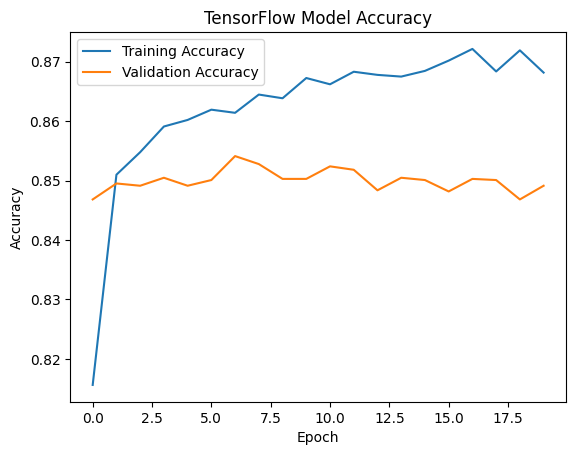

In [58]:
plt.plot(tensorflow_history.history["accuracy"], label="Training Accuracy")
plt.plot(tensorflow_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("TensorFlow Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

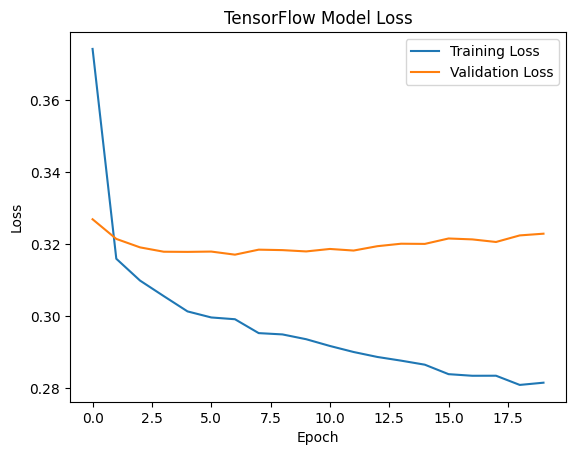

In [59]:
plt.plot(tensorflow_history.history["loss"], label="Training Loss")
plt.plot(tensorflow_history.history["val_loss"], label="Validation Loss")

plt.title("TensorFlow Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [60]:
tf_probabilities = tensorflow_model.predict(X_test_processed).ravel()

tf_probabilities[:10]


204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([8.4872752e-02, 4.4407820e-06, 8.1952709e-01, 6.0196340e-01,
       1.3224520e-02, 5.8575141e-01, 2.7283591e-01, 5.0066404e-02,
       2.2895006e-02, 9.1947624e-03], dtype=float32)

In [61]:
tf_predictions = (tf_probabilities >= 0.5).astype(int)

tf_predictions[:10]

array([0, 0, 1, 1, 0, 1, 0, 0, 0, 0])

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

tf_accuracy = accuracy_score(y_test, tf_predictions)
tf_precision = precision_score(y_test, tf_predictions)
tf_recall = recall_score(y_test, tf_predictions)
tf_f1 = f1_score(y_test, tf_predictions)

print("TensorFlow/Keras Results")
print("Accuracy:", tf_accuracy)
print("Precision:", tf_precision)
print("Recall:", tf_recall)
print("F1 Score:", tf_f1)

TensorFlow/Keras Results
Accuracy: 0.8527560264087211
Precision: 0.7036789297658863
Recall: 0.6709183673469388
F1 Score: 0.6869082598759386


In [63]:
print(classification_report(y_test, tf_predictions))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4945
           1       0.70      0.67      0.69      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.79      0.80      6513
weighted avg       0.85      0.85      0.85      6513



In [64]:
tf_cm = confusion_matrix(y_test, tf_predictions)

tf_cm

array([[4502,  443],
       [ 516, 1052]])

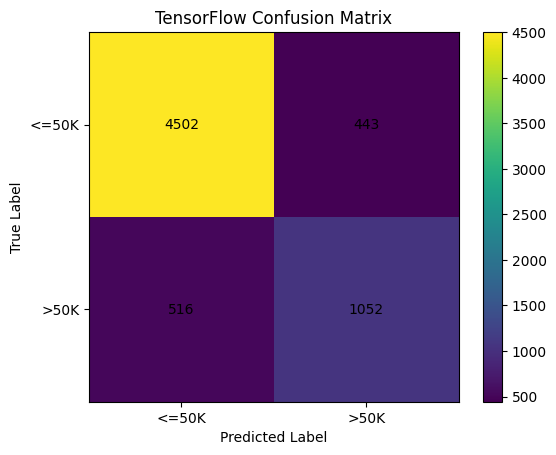

In [65]:
plt.imshow(tf_cm)
plt.title("TensorFlow Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])

for i in range(tf_cm.shape[0]):
    for j in range(tf_cm.shape[1]):
        plt.text(j, i, tf_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 7. PyTorch Neural Network

In this section, we build the same type of neural network using PyTorch.

The aim is to compare PyTorch with TensorFlow/Keras using the same processed training and test data.

The model structure will be similar:

- Input layer based on processed feature count
- Hidden layer 1 with 64 neurons and ReLU
- Dropout layer
- Hidden layer 2 with 32 neurons and ReLU
- Output layer with 1 neuron

In PyTorch, we will use `BCEWithLogitsLoss`, so the final layer does not need a sigmoid during training.

In [66]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [67]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([26048, 104])
y_train_tensor: torch.Size([26048, 1])
X_test_tensor: torch.Size([6513, 104])
y_test_tensor: torch.Size([6513, 1])


In [69]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [71]:
class PyTorchAdultIncomeModel(nn.Module):
    def __init__(self, input_size):
        super(PyTorchAdultIncomeModel, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [72]:
torch.manual_seed(42)

pytorch_model = PyTorchAdultIncomeModel(input_dim)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=0.001)

print(pytorch_model)

PyTorchAdultIncomeModel(
  (network): Sequential(
    (0): Linear(in_features=104, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [73]:
epochs = 20
pytorch_train_losses = []

for epoch in range(epochs):
    pytorch_model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        logits = pytorch_model(batch_X)

        # Calculate loss
        loss = loss_function(logits, batch_y)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    pytorch_train_losses.append(average_loss)

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {average_loss:.4f}")

Epoch 1/20, Loss: 0.3607
Epoch 2/20, Loss: 0.3119
Epoch 3/20, Loss: 0.3084
Epoch 4/20, Loss: 0.3048
Epoch 5/20, Loss: 0.3026
Epoch 6/20, Loss: 0.3019
Epoch 7/20, Loss: 0.2980
Epoch 8/20, Loss: 0.2976
Epoch 9/20, Loss: 0.2963
Epoch 10/20, Loss: 0.2955
Epoch 11/20, Loss: 0.2934
Epoch 12/20, Loss: 0.2917
Epoch 13/20, Loss: 0.2899
Epoch 14/20, Loss: 0.2897
Epoch 15/20, Loss: 0.2874
Epoch 16/20, Loss: 0.2870
Epoch 17/20, Loss: 0.2849
Epoch 18/20, Loss: 0.2846
Epoch 19/20, Loss: 0.2834
Epoch 20/20, Loss: 0.2829


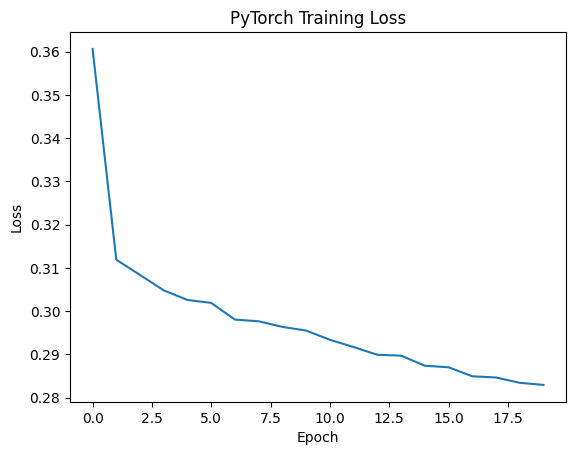

In [74]:
plt.plot(pytorch_train_losses)

plt.title("PyTorch Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [75]:
pytorch_model.eval()

with torch.no_grad():
    test_logits = pytorch_model(X_test_tensor)
    test_probabilities = torch.sigmoid(test_logits)
    pytorch_predictions = (test_probabilities >= 0.5).int().numpy().ravel()

pytorch_predictions[:10]

array([0, 0, 1, 1, 0, 1, 0, 0, 0, 0], dtype=int32)

In [76]:
pytorch_accuracy = accuracy_score(y_test, pytorch_predictions)
pytorch_precision = precision_score(y_test, pytorch_predictions)
pytorch_recall = recall_score(y_test, pytorch_predictions)
pytorch_f1 = f1_score(y_test, pytorch_predictions)

print("PyTorch Results")
print("Accuracy:", pytorch_accuracy)
print("Precision:", pytorch_precision)
print("Recall:", pytorch_recall)
print("F1 Score:", pytorch_f1)

PyTorch Results
Accuracy: 0.8536772608628896
Precision: 0.7229876722262509
Recall: 0.6358418367346939
F1 Score: 0.6766202918221921


In [77]:
print(classification_report(y_test, pytorch_predictions))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      4945
           1       0.72      0.64      0.68      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.85      0.85      6513



In [79]:
pytorch_cm = confusion_matrix(y_test, pytorch_predictions)

pytorch_cm

array([[4563,  382],
       [ 571,  997]])

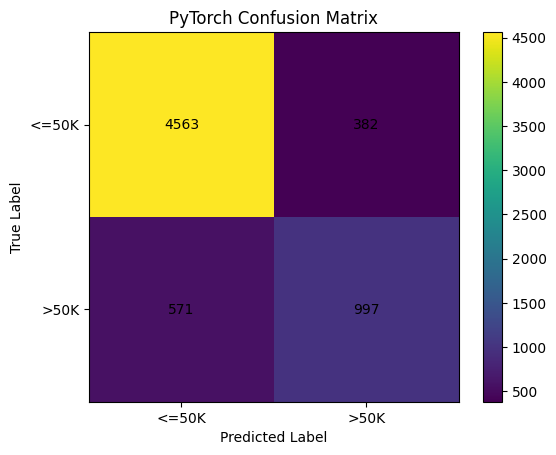

In [80]:
plt.imshow(pytorch_cm)
plt.title("PyTorch Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])

for i in range(pytorch_cm.shape[0]):
    for j in range(pytorch_cm.shape[1]):
        plt.text(j, i, pytorch_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## PyTorch Training Observation

The PyTorch model was trained using a manual training loop.

Unlike TensorFlow/Keras, PyTorch requires us to explicitly write the training steps:

1. Forward pass
2. Calculate loss
3. Clear old gradients
4. Backpropagation
5. Update weights

The model uses `BCEWithLogitsLoss`, which internally combines sigmoid and binary cross entropy. Therefore, sigmoid is applied only during prediction.

## 8. Model Comparison

Now we compare the TensorFlow/Keras and PyTorch models using the same metrics:

- Accuracy
- Precision
- Recall
- F1 Score

The same train/test split and same preprocessing were used for both models, so the comparison is fair.

In [81]:
comparison_df = pd.DataFrame({
    "Model": ["TensorFlow/Keras", "PyTorch"],
    "Accuracy": [tf_accuracy, pytorch_accuracy],
    "Precision": [tf_precision, pytorch_precision],
    "Recall": [tf_recall, pytorch_recall],
    "F1 Score": [tf_f1, pytorch_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,TensorFlow/Keras,0.852756,0.703679,0.670918,0.686908
1,PyTorch,0.853677,0.722988,0.635842,0.676620


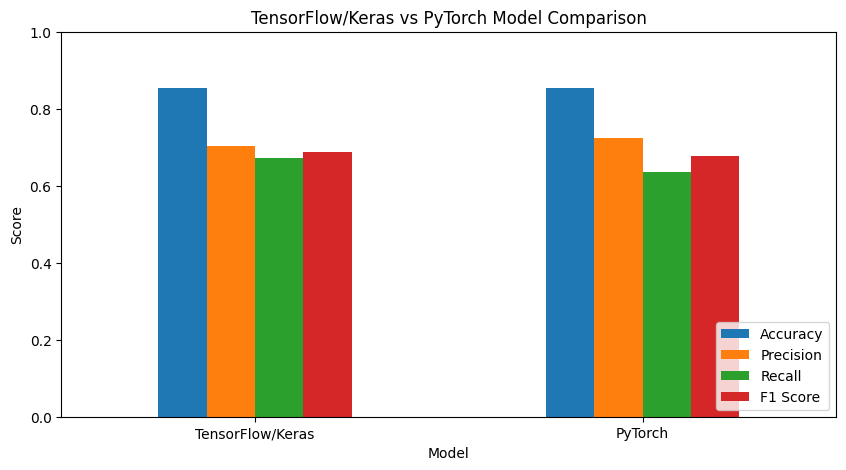

In [82]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("TensorFlow/Keras vs PyTorch Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

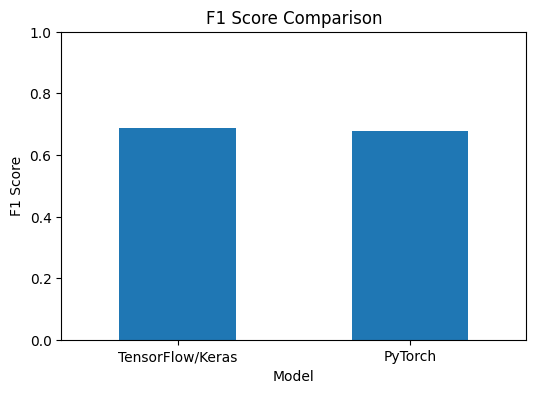

In [83]:
comparison_df.set_index("Model")["F1 Score"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

## Final Model Comparison Observation

Both TensorFlow/Keras and PyTorch produced similar results.

Accuracy was around 85%, meaning both models correctly predicted most records.

However, because the dataset is imbalanced, accuracy alone is not enough. The F1 score is more useful for judging performance on the `>50K` class.

In this run:

- TensorFlow/Keras and PyTorch had very close accuracy.
- TensorFlow/Keras achieved a slightly better balance between precision and recall.
- PyTorch achieved similar performance but with a more manual training process.

The main learning from this exercise is that both frameworks can build similar neural networks, but TensorFlow/Keras provides a simpler high-level `.fit()` workflow, while PyTorch gives more control through a manual training loop.

In [84]:
comparison_df.to_csv("../reports/notebook_model_comparison.csv", index=False)

print("Model comparison saved to reports folder.")

Model comparison saved to reports folder.


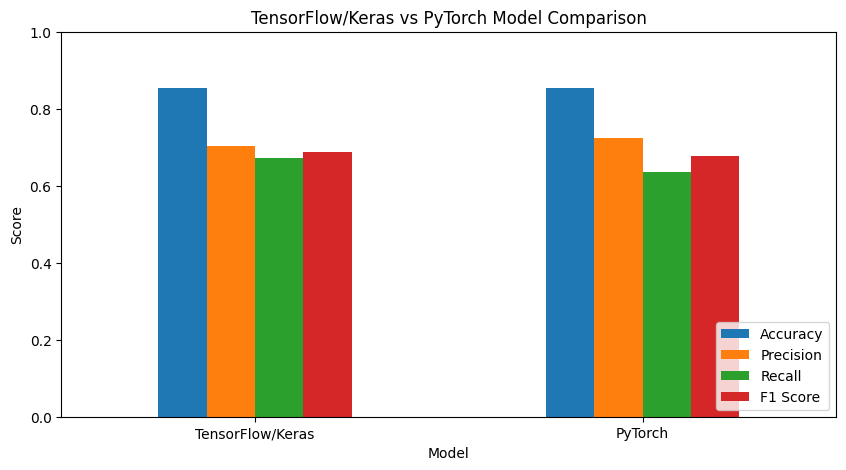

In [85]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("TensorFlow/Keras vs PyTorch Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")

plt.savefig("../reports/model_comparison_bar_chart.png", bbox_inches="tight")
plt.show()

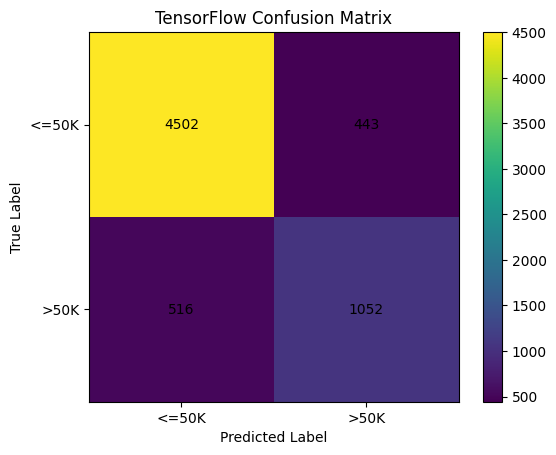

In [86]:
plt.imshow(tf_cm)
plt.title("TensorFlow Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])

for i in range(tf_cm.shape[0]):
    for j in range(tf_cm.shape[1]):
        plt.text(j, i, tf_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.savefig("../reports/tensorflow_confusion_matrix.png", bbox_inches="tight")
plt.show()

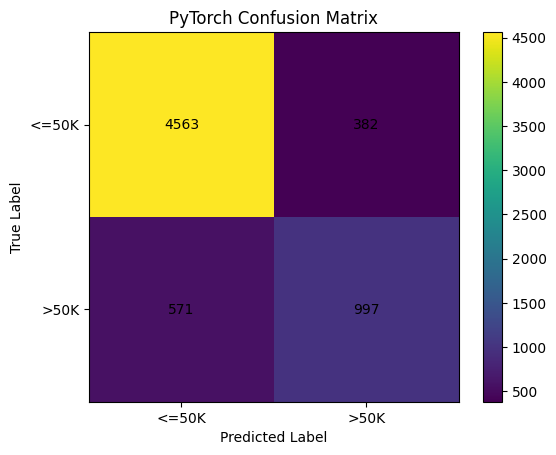

In [87]:
plt.imshow(pytorch_cm)
plt.title("PyTorch Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])

for i in range(pytorch_cm.shape[0]):
    for j in range(pytorch_cm.shape[1]):
        plt.text(j, i, pytorch_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.savefig("../reports/pytorch_confusion_matrix.png", bbox_inches="tight")
plt.show()

## Final Summary

This notebook replicated the Customer Churn style workflow using the Adult Income Classification dataset.

The full workflow included:

1. Loading and inspecting the dataset
2. Cleaning hidden missing values stored as `?`
3. Performing exploratory data analysis
4. Splitting features and target
5. Applying preprocessing using `ColumnTransformer`
6. Training a TensorFlow/Keras neural network
7. Training a PyTorch neural network
8. Comparing both models using classification metrics

The dataset was imbalanced, with more `<=50K` records than `>50K` records.

Both models achieved similar accuracy, but F1 score was used as an important comparison metric because of the imbalance.

This exercise helped compare the high-level TensorFlow/Keras training workflow with the more manual PyTorch training loop.